In [15]:
# Preparetion du dataset 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SPP = pd.read_csv("../data/SPP.csv")

In [16]:
TARGET = "Exam_Score"

In [17]:
# 1. Nombre de lignes et de colonnes 
print(SPP.shape)

(6607, 21)


In [18]:
# 2. Noms de colonnes 
print(SPP.columns.tolist())

['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'School_Type', 'Physical_Activity', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score', 'Electricity_Access', 'Region', 'Transport_Mode', 'Class_Size', 'Language_Section']


In [19]:
print(SPP.dtypes)

Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
School_Type                     str
Physical_Activity             int64
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
Electricity_Access              str
Region                          str
Transport_Mode                  str
Class_Size                    int64
Language_Section                str
dtype: object


In [20]:
# 4. Valeurs manquantes 
print(SPP.isnull().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
School_Type                    0
Physical_Activity              0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
Electricity_Access             0
Region                         0
Transport_Mode                 0
Class_Size                     0
Language_Section               0
dtype: int64


In [21]:
# 5. Doublons
print(SPP.duplicated().sum())

0


In [22]:
# 6. Separation des categorielles des numeriques
numeric_columns = SPP.select_dtypes(include=np.number).columns.tolist()

categorical_columns = SPP.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numériques :")
print(numeric_columns)

print("\nVariables catégorielles :")
print(categorical_columns)

Variables numériques :
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score', 'Class_Size']

Variables catégorielles :
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Internet_Access', 'Family_Income', 'School_Type', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Electricity_Access', 'Region', 'Transport_Mode', 'Language_Section']


In [23]:
# 7, Min max
for col in numeric_columns:
    print(
        f"{col} : min = {SPP[col].min()}, "
        f"max = {SPP[col].max()}"
    )

Hours_Studied : min = 1, max = 44
Attendance : min = 60, max = 100
Sleep_Hours : min = 4, max = 10
Previous_Scores : min = 50, max = 100
Tutoring_Sessions : min = 0, max = 8
Physical_Activity : min = 0, max = 6
Exam_Score : min = 55, max = 101
Class_Size : min = 20, max = 199


count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


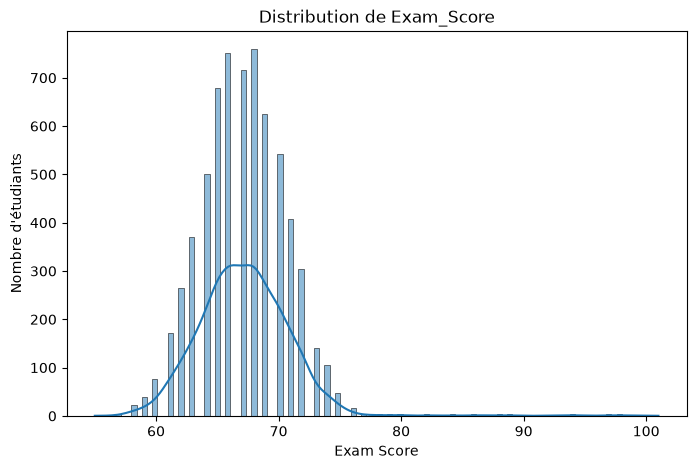

In [25]:
# 8. Distribution de la target
print(SPP[TARGET].describe())

plt.figure(figsize=(8, 5))

sns.histplot(SPP[TARGET], kde=True)

plt.title("Distribution de Exam_Score")
plt.xlabel("Exam Score")
plt.ylabel("Nombre d'étudiants")

plt.show()

In [26]:
# 9. valeurs aberantes
for col in numeric_columns:

    Q1 = SPP[col].quantile(0.25)
    Q3 = SPP[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = SPP[
        (SPP[col] < lower_bound) |
        (SPP[col] > upper_bound)
    ]

    print(f"{col} : {len(outliers)} outliers")

Hours_Studied : 43 outliers
Attendance : 0 outliers
Sleep_Hours : 0 outliers
Previous_Scores : 0 outliers
Tutoring_Sessions : 430 outliers
Physical_Activity : 0 outliers
Exam_Score : 104 outliers
Class_Size : 0 outliers


In [28]:
# 10. Cardinalite des variables categorielles
for col in categorical_columns:
    print(f"\n\n{col}")
    print("Cardinalité :", SPP[col].nunique())
    print(SPP[col].value_counts())



Parental_Involvement
Cardinalité : 3
Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64


Access_to_Resources
Cardinalité : 3
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64


Extracurricular_Activities
Cardinalité : 2
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64


Internet_Access
Cardinalité : 2
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64


Family_Income
Cardinalité : 3
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64


School_Type
Cardinalité : 2
School_Type
Public     4598
Private    2009
Name: count, dtype: int64


Parental_Education_Level
Cardinalité : 3
Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64


Distance_from_Home
Cardinalité : 3
Distance_from_Home
Near        3884
Moderate    1998
Far          658
Name: count, dtype: int64


Gender
Ca

                   Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  \
Hours_Studied           1.000000   -0.009908     0.010977         0.024846   
Attendance             -0.009908    1.000000    -0.015918        -0.020186   
Sleep_Hours             0.010977   -0.015918     1.000000        -0.021750   
Previous_Scores         0.024846   -0.020186    -0.021750         1.000000   
Tutoring_Sessions      -0.014282    0.014324    -0.012216        -0.013122   
Physical_Activity       0.004624   -0.022435    -0.000378        -0.011274   
Exam_Score              0.445455    0.581072    -0.017022         0.175079   
Class_Size             -0.010515    0.007599    -0.004143        -0.002751   

                   Tutoring_Sessions  Physical_Activity  Exam_Score  \
Hours_Studied              -0.014282           0.004624    0.445455   
Attendance                  0.014324          -0.022435    0.581072   
Sleep_Hours                -0.012216          -0.000378   -0.017022   
Previous_Scor

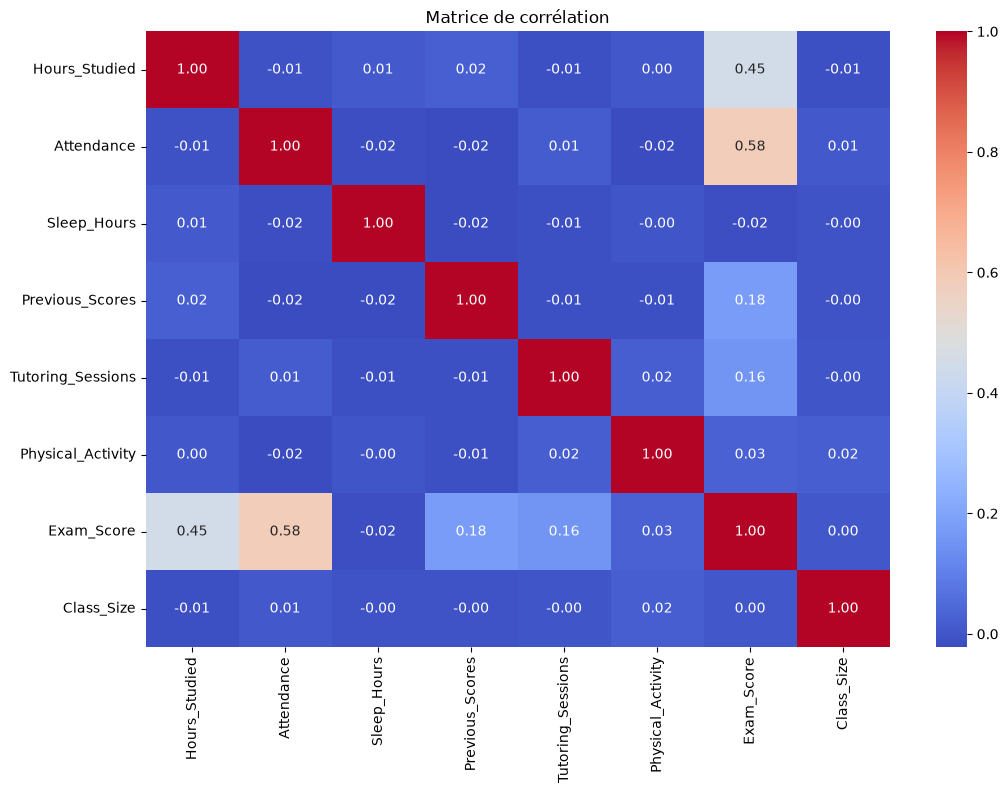

In [30]:
# 11. Matrice de correlation
correlation_matrix = SPP[numeric_columns].corr()

print(correlation_matrix)

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation")

plt.show()

In [31]:
# 12. Coherence logique metier 
invalid_scores = SPP[
    (SPP["Exam_Score"] < 0) |
    (SPP["Exam_Score"] > 100)
]

print(invalid_scores)

invalid_attendance = SPP[
    (SPP["Attendance"] < 0) |
    (SPP["Attendance"] > 100)
]

print(invalid_attendance)

invalid_hours = SPP[
    SPP["Hours_Studied"] < 0
]

print(invalid_hours)

invalid_sleep = SPP[
    (SPP["Sleep_Hours"] < 0) |
    (SPP["Sleep_Hours"] > 24)
]

print(invalid_sleep)

for col in categorical_columns:
    print(f"\n{col}")
    print(SPP[col].unique())

      Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
1525             27          98                  Low              Medium   

     Extracurricular_Activities  Sleep_Hours  Previous_Scores Internet_Access  \
1525                        Yes            6               93              No   

      Tutoring_Sessions Family_Income  ... Physical_Activity  \
1525                  5          High  ...                 3   

      Parental_Education_Level Distance_from_Home  Gender Exam_Score  \
1525               High School           Moderate  Female        101   

      Electricity_Access Region Transport_Mode Class_Size  Language_Section  
1525                  no   East    Private car         65        Anglophone  

[1 rows x 21 columns]
Empty DataFrame
Columns: [Hours_Studied, Attendance, Parental_Involvement, Access_to_Resources, Extracurricular_Activities, Sleep_Hours, Previous_Scores, Internet_Access, Tutoring_Sessions, Family_Income, School_Type, Physical_Acti